In [1]:
import pandas as pd
import polars as pl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc

### Load Data

In [2]:
path = 'Raw_Data'

orders = pl.read_csv(os.path.join(path,'orders.csv'), schema_overrides={
    'order_id': pl.Int32,
    'user_id': pl.Int32,
    'order_number': pl.UInt8,
    'order_dow': pl.UInt8,
    'order_hour_of_day': pl.UInt8,
    'days_since_prior_order': pl.Float32
})

priors = pl.read_csv(os.path.join(path,'order_products__prior.csv'), schema_overrides={
    'order_id': pl.Int32,
    'product_id': pl.Int32, 
    'add_to_cart_order': pl.UInt8,
    'reordered': pl.UInt8
})

train = pl.read_csv(os.path.join(path,'order_products__train.csv'), schema_overrides={
    'order_id': pl.Int32,
    'product_id': pl.Int32,
    'add_to_cart_order': pl.UInt8,
    'reordered': pl.UInt8
})

products = pl.read_csv(os.path.join(path,'products.csv'), schema_overrides={
    'product_id': pl.Int32,
    'aisle_id': pl.Int32,
    'department_id': pl.Int32
})


In [3]:
orders.head()

order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
i32,i32,str,u8,u8,u8,f32
2539329,1,"""prior""",1,2,8,null
2398795,1,"""prior""",2,3,7,15.0
473747,1,"""prior""",3,3,12,21.0
2254736,1,"""prior""",4,4,7,29.0
431534,1,"""prior""",5,4,15,28.0


### Preprocess

In [4]:
null_count = orders.select(pl.all().null_count())
print("Missing Values:")
print(null_count)

orders = orders.with_columns(
    pl.col("days_since_prior_order").fill_null(0).cast(pl.Float32)
)


Missing Values:
shape: (1, 7)
┌──────────┬─────────┬──────────┬──────────────┬───────────┬───────────────────┬───────────────────┐
│ order_id ┆ user_id ┆ eval_set ┆ order_number ┆ order_dow ┆ order_hour_of_day ┆ days_since_prior_ │
│ ---      ┆ ---     ┆ ---      ┆ ---          ┆ ---       ┆ ---               ┆ order             │
│ u32      ┆ u32     ┆ u32      ┆ u32          ┆ u32       ┆ u32               ┆ ---               │
│          ┆         ┆          ┆              ┆           ┆                   ┆ u32               │
╞══════════╪═════════╪══════════╪══════════════╪═══════════╪═══════════════════╪═══════════════════╡
│ 0        ┆ 0       ┆ 0        ┆ 0            ┆ 0         ┆ 0                 ┆ 206209            │
└──────────┴─────────┴──────────┴──────────────┴───────────┴───────────────────┴───────────────────┘


### EDA

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

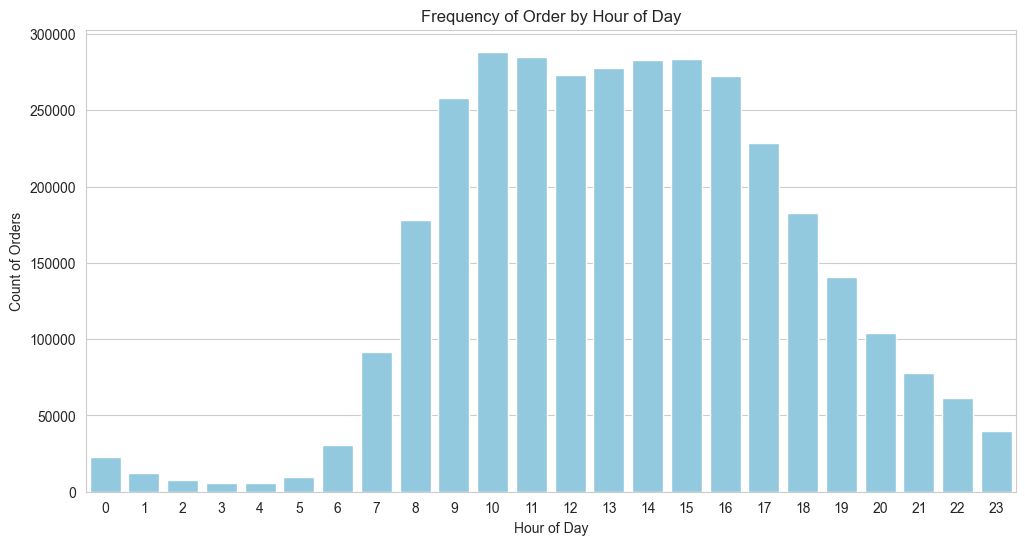

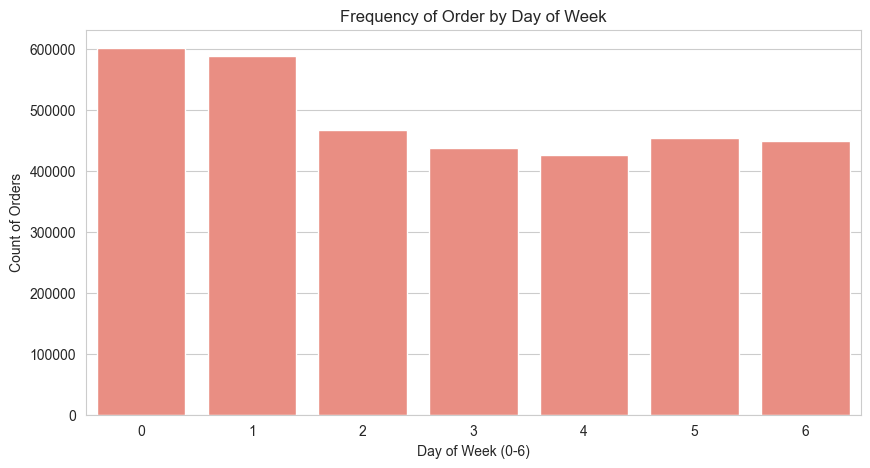

In [6]:
orders_by_hour = (
    orders
    .group_by("order_hour_of_day")
    .len().rename({"len": "count"})
    .sort("order_hour_of_day")
)

orders_by_hour_pd = orders_by_hour.to_pandas()
# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=orders_by_hour_pd, x="order_hour_of_day", y="count", color='skyblue')
plt.title("Frequency of Order by Hour of Day")
plt.ylabel("Count of Orders")
plt.xlabel("Hour of Day")
plt.show()

# 0 = Sunday, 1 = Monday ... 
orders_by_dow = (
    orders
    .group_by("order_dow")
    .len().rename({"len": "count"})
    .sort("order_dow")
)

orders_by_dow_pd = orders_by_dow.to_pandas()
plt.figure(figsize=(10, 5))
sns.barplot(data=orders_by_dow_pd, x="order_dow", y="count", color='salmon')
plt.title("Frequency of Order by Day of Week")
plt.ylabel("Count of Orders")
plt.xlabel("Day of Week (0-6)")
plt.show()

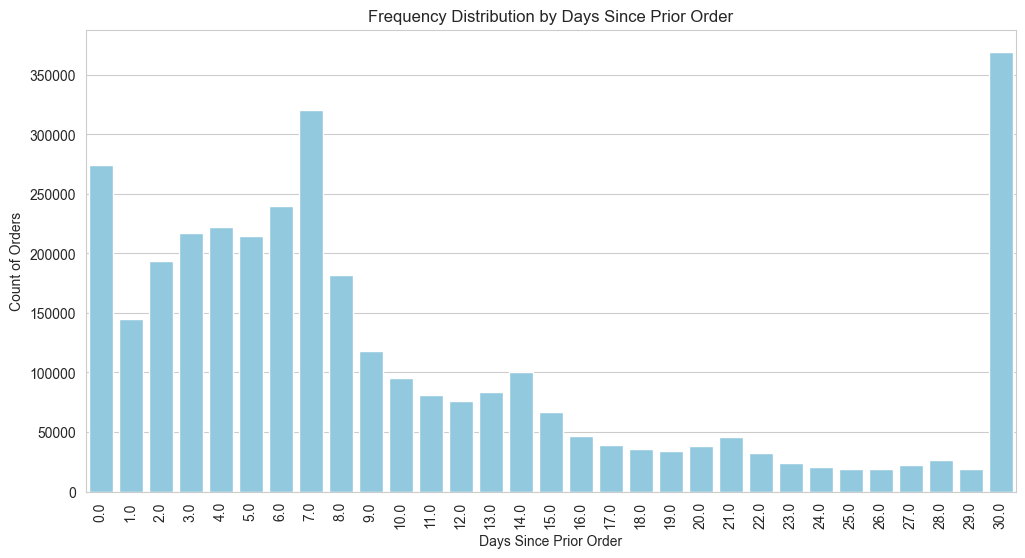

In [7]:

days_dist = (
    orders
    .group_by("days_since_prior_order")
    .len().rename({"len": "count"})
    .sort("days_since_prior_order")
)

day_dist_pd = days_dist.to_pandas()

plt.figure(figsize=(12, 6))

sns.barplot(data=day_dist_pd, x="days_since_prior_order", y="count", color='skyblue')
plt.title("Frequency Distribution by Days Since Prior Order")
plt.ylabel("Count of Orders")
plt.xlabel("Days Since Prior Order")
plt.xticks(rotation=90)
plt.show()

Top 10 Best Selling Products:
shape: (10, 2)
┌────────────────────────┬────────┐
│ product_name           ┆ count  │
│ ---                    ┆ ---    │
│ str                    ┆ u32    │
╞════════════════════════╪════════╡
│ Banana                 ┆ 472565 │
│ Bag of Organic Bananas ┆ 379450 │
│ Organic Strawberries   ┆ 264683 │
│ Organic Baby Spinach   ┆ 241921 │
│ Organic Hass Avocado   ┆ 213584 │
│ Organic Avocado        ┆ 176815 │
│ Large Lemon            ┆ 152657 │
│ Strawberries           ┆ 142951 │
│ Limes                  ┆ 140627 │
│ Organic Whole Milk     ┆ 137905 │
└────────────────────────┴────────┘


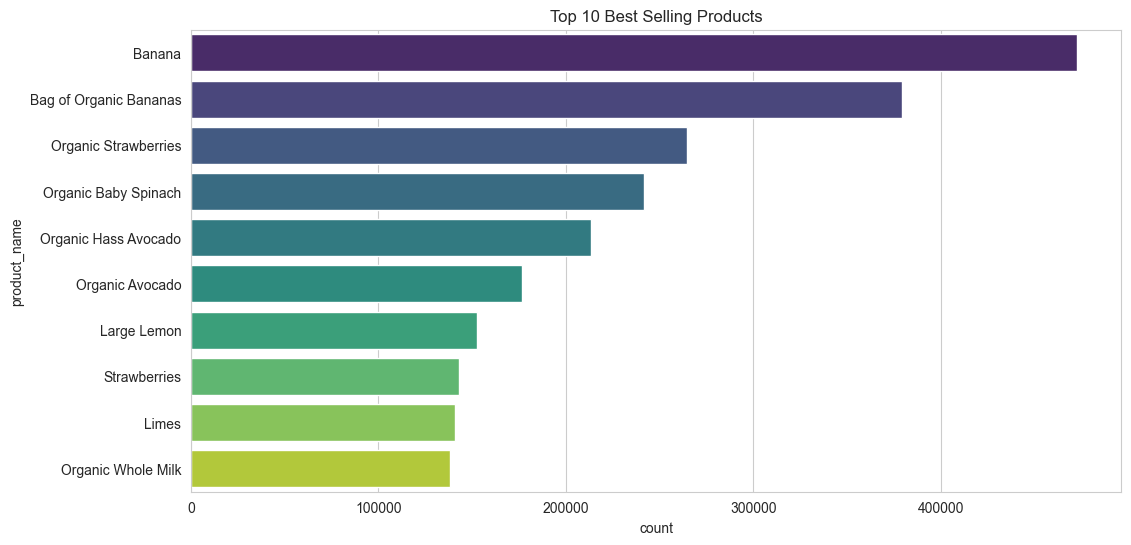

In [8]:
temp_priors = priors.select(["product_id", "reordered"])
temp_products = products.select(["product_id", "product_name", "department_id"])

# Join
merged_products = temp_priors.join(temp_products, on="product_id", how="left")

# Top 10 Product
top_products = (
    merged_products
    .group_by("product_name")
    .len().rename({"len": "count"})
    .sort("count", descending=True)
    .head(10)
)
top_products_pd = top_products.to_pandas()
print("Top 10 Best Selling Products:")
print(top_products)

# Plot 
plt.figure(figsize=(12, 6))
sns.barplot(data = top_products_pd , y = "product_name" , x = "count" , palette="viridis")
plt.title("Top 10 Best Selling Products")
plt.show()

In [9]:
#
product_reorder_rate = (
    merged_products
    .group_by("product_name")
    .agg([
        pl.len().alias("total_orders"),
        pl.col("reordered").mean().alias("reorder_rate")
    ])

    .filter(pl.col("total_orders") > 2000)
    .sort("reorder_rate", descending=True)
    .head(10)
)

print("Top 10 Products with Highest Reorder Rate:")
print(product_reorder_rate)

Top 10 Products with Highest Reorder Rate:
shape: (10, 3)
┌─────────────────────────────────┬──────────────┬──────────────┐
│ product_name                    ┆ total_orders ┆ reorder_rate │
│ ---                             ┆ ---          ┆ ---          │
│ str                             ┆ u32          ┆ f64          │
╞═════════════════════════════════╪══════════════╪══════════════╡
│ Half And Half Ultra Pasteurize… ┆ 2921         ┆ 0.861691     │
│ Whole Organic Omega 3 Milk      ┆ 9108         ┆ 0.860233     │
│ Organic Lactose Free Whole Mil… ┆ 8477         ┆ 0.85903      │
│ Organic Homogenized Whole Milk  ┆ 3970         ┆ 0.857683     │
│ Milk, Organic, Vitamin D        ┆ 20198        ┆ 0.854342     │
│ Organic Reduced Fat Milk        ┆ 35663        ┆ 0.850686     │
│ Goat Milk                       ┆ 5185         ┆ 0.849952     │
│ Banana                          ┆ 472565       ┆ 0.843501     │
│ Organic  Whole Milk             ┆ 9842         ┆ 0.841191     │
│ Organic Lowfat 1

### Feature Engineer

In [10]:
priors_sel = priors.select(['order_id', 'product_id', 'reordered'])
orders_sel = orders.select(['order_id', 'user_id', 'order_number', 'days_since_prior_order'])

priors_orders_detail = priors_sel.join(orders_sel, on="order_id")
print(priors_orders_detail.head())

shape: (5, 6)
┌──────────┬────────────┬───────────┬─────────┬──────────────┬────────────────────────┐
│ order_id ┆ product_id ┆ reordered ┆ user_id ┆ order_number ┆ days_since_prior_order │
│ ---      ┆ ---        ┆ ---       ┆ ---     ┆ ---          ┆ ---                    │
│ i32      ┆ i32        ┆ u8        ┆ i32     ┆ u8           ┆ f32                    │
╞══════════╪════════════╪═══════════╪═════════╪══════════════╪════════════════════════╡
│ 2        ┆ 33120      ┆ 1         ┆ 202279  ┆ 3            ┆ 8.0                    │
│ 2        ┆ 28985      ┆ 1         ┆ 202279  ┆ 3            ┆ 8.0                    │
│ 2        ┆ 9327       ┆ 0         ┆ 202279  ┆ 3            ┆ 8.0                    │
│ 2        ┆ 45918      ┆ 1         ┆ 202279  ┆ 3            ┆ 8.0                    │
│ 2        ┆ 30035      ┆ 0         ┆ 202279  ┆ 3            ┆ 8.0                    │
└──────────┴────────────┴───────────┴─────────┴──────────────┴────────────────────────┘


In [11]:
prod_feats = (
    priors_orders_detail
    .group_by("product_id")
    .agg([
        pl.len().alias("prod_total_orders"),       
        pl.col("reordered").mean().alias("prod_reorder_ratio") 
    ])
)

prod_feats.head()

product_id,prod_total_orders,prod_reorder_ratio
i32,u32,f64
45234,1045,0.620096
26221,1254,0.598086
3442,637,0.354788
33450,11,0.090909
38809,1026,0.712476


In [12]:
user_feats = (
    orders  
    .filter(pl.col("eval_set") == "prior") 
    .group_by("user_id")
    .agg([
        pl.max("order_number").alias("user_total_orders"),     
        pl.mean("days_since_prior_order").alias("user_avg_days_between_orders"), 
        pl.len().alias("user_sum_orders") 
    ])
)

print("User Features Created:", user_feats.shape)
user_feats.head()

User Features Created: (206209, 4)


user_id,user_total_orders,user_avg_days_between_orders,user_sum_orders
i32,u8,f32,u32
116689,3,12.333333,3
148555,7,11.428572,7
176074,12,17.75,12
23744,99,3.222222,99
11412,26,8.769231,26


In [13]:
up_feats = (
    priors_orders_detail
    .group_by(["user_id", "product_id"])
    .agg([
        pl.len().alias("up_total_bought"),          
        pl.max("order_number").alias("up_last_order_number"), 
        pl.mean("reordered").alias("up_reorder_ratio") 
    ])
)

up_feats.head

<bound method DataFrame.head of shape: (13_307_953, 5)
┌─────────┬────────────┬─────────────────┬──────────────────────┬──────────────────┐
│ user_id ┆ product_id ┆ up_total_bought ┆ up_last_order_number ┆ up_reorder_ratio │
│ ---     ┆ ---        ┆ ---             ┆ ---                  ┆ ---              │
│ i32     ┆ i32        ┆ u32             ┆ u8                   ┆ f64              │
╞═════════╪════════════╪═════════════════╪══════════════════════╪══════════════════╡
│ 55544   ┆ 28849      ┆ 4               ┆ 4                    ┆ 0.75             │
│ 94932   ┆ 45066      ┆ 6               ┆ 50                   ┆ 0.833333         │
│ 92324   ┆ 32030      ┆ 37              ┆ 64                   ┆ 0.972973         │
│ 201181  ┆ 38720      ┆ 1               ┆ 1                    ┆ 0.0              │
│ 106645  ┆ 47543      ┆ 2               ┆ 2                    ┆ 0.5              │
│ …       ┆ …          ┆ …               ┆ …                    ┆ …                │
│ 26440   

In [14]:
import gc
del priors_sel
del orders_sel
del priors_orders_detail
gc.collect()

22584

In [15]:
train_users = orders.filter(pl.col("eval_set") == "train").select(["user_id", "order_id"])

# Join Candidates into Train Users
train_candidates = up_feats.join(train_users, on="user_id", how="inner")

print(f"Candidates Count: {train_candidates.height:,}")

# Merge Features 
# Join User Features
train_df = train_candidates.join(user_feats, on="user_id", how="left")

# Join Product Features
train_df = train_df.join(prod_feats, on="product_id", how="left")

# Create Target Label 
train_labels = train.select([
    pl.col("order_id"),
    pl.col("product_id"),
    pl.col("reordered").alias("label") 
])
train_df = train_df.join(train_labels, on=["order_id", "product_id"], how="left")

train_df = train_df.with_columns(
    pl.col("label").fill_null(0).cast(pl.UInt8)
)

print(f"Shape: {train_df.shape}")
print(train_df.head())


del train_candidates
del train_labels
gc.collect()

Candidates Count: 8,474,661
Shape: (8474661, 12)
shape: (5, 12)
┌─────────┬────────────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬───────┐
│ user_id ┆ product_id ┆ up_total_b ┆ up_last_or ┆ … ┆ user_sum_o ┆ prod_total ┆ prod_reor ┆ label │
│ ---     ┆ ---        ┆ ought      ┆ der_number ┆   ┆ rders      ┆ _orders    ┆ der_ratio ┆ ---   │
│ i32     ┆ i32        ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ u8    │
│         ┆            ┆ u32        ┆ u8         ┆   ┆ u32        ┆ u32        ┆ f64       ┆       │
╞═════════╪════════════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════╡
│ 55544   ┆ 28849      ┆ 4          ┆ 4          ┆ … ┆ 4          ┆ 27924      ┆ 0.580325  ┆ 0     │
│ 92324   ┆ 32030      ┆ 37         ┆ 64         ┆ … ┆ 64         ┆ 4484       ┆ 0.641615  ┆ 1     │
│ 106645  ┆ 47543      ┆ 2          ┆ 2          ┆ … ┆ 18         ┆ 61         ┆ 0.344262  ┆ 0     │
│ 26550   ┆ 39794      ┆ 1 

0

In [16]:
train_df.columns

['user_id',
 'product_id',
 'up_total_bought',
 'up_last_order_number',
 'up_reorder_ratio',
 'order_id',
 'user_total_orders',
 'user_avg_days_between_orders',
 'user_sum_orders',
 'prod_total_orders',
 'prod_reorder_ratio',
 'label']

### Model Training

In [17]:
from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, roc_auc_score
import time

In [18]:

train_pd = train_df.to_pandas()
unique_users = train_pd['user_id'].unique()
print(f"Total Users: {len(unique_users)}")


train_users, val_users = train_test_split(unique_users, test_size=0.2, random_state=42)

print(f"Train Users: {len(train_users)}")
print(f"Validation Users: {len(val_users)}")


train_set = train_pd[train_pd['user_id'].isin(train_users)]
val_set = train_pd[train_pd['user_id'].isin(val_users)]

features = [
    'user_total_orders', 'user_avg_days_between_orders',
    'prod_total_orders', 'prod_reorder_ratio',
    'up_total_bought', 'up_reorder_ratio', 'up_last_order_number'
]
target = 'label'

X_train = train_set[features]
y_train = train_set[target]

X_val = val_set[features]
y_val = val_set[target]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

# Clean memory
import gc
del train_set, val_set, unique_users, train_users, val_users
gc.collect()

Total Users: 131209
Train Users: 104967
Validation Users: 26242
X_train shape: (6776186, 7)
X_val shape: (1698475, 7)


0

In [19]:
results = {}

In [20]:
start = time.time()
lgb = LGBMClassifier(n_estimators=100, random_state=42) 
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_val)
lgb_time = time.time() - start

results['LightGBM'] = {
    'F1-Score': f1_score(y_val, lgb_pred),
    'AUC': roc_auc_score(y_val, lgb.predict_proba(X_val)[:, 1]),
    'Time (s)': lgb_time
}

[LightGBM] [Info] Number of positive: 663355, number of negative: 6112831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1093
[LightGBM] [Info] Number of data points in the train set: 6776186, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.097895 -> initscore=-2.220835
[LightGBM] [Info] Start training from score -2.220835


In [21]:
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)
xgb_time = time.time() - start

results['XGBoost'] = {
    'F1-Score': f1_score(y_val, xgb_pred),
    'AUC': roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1]),
    'Time (s)': xgb_time
}

In [22]:
start = time.time()
cat = CatBoostClassifier(n_estimators=100, random_state=42, verbose=0)
cat.fit(X_train, y_train)
cat_pred = cat.predict(X_val)
cat_time = time.time() - start

results['CatBoost'] = {
    'F1-Score': f1_score(y_val, cat_pred),
    'AUC': roc_auc_score(y_val, cat.predict_proba(X_val)[:, 1]),
    'Time (s)': cat_time
}

### Model Evaluate

In [23]:
print("\n--- Model Comparison Results ---")
pd.DataFrame(results).T


--- Model Comparison Results ---


,F1-Score,AUC,Time (s)
LightGBM,0.237588,0.825724,31.099177
XGBoost,0.242748,0.826641,158.675267
CatBoost,0.243059,0.826286,38.658009


--- Optimization Results ---
Best Threshold: 0.22
Best F1-Score:  0.4269
(Score increased to 0.4269 at Threshold 0.22)



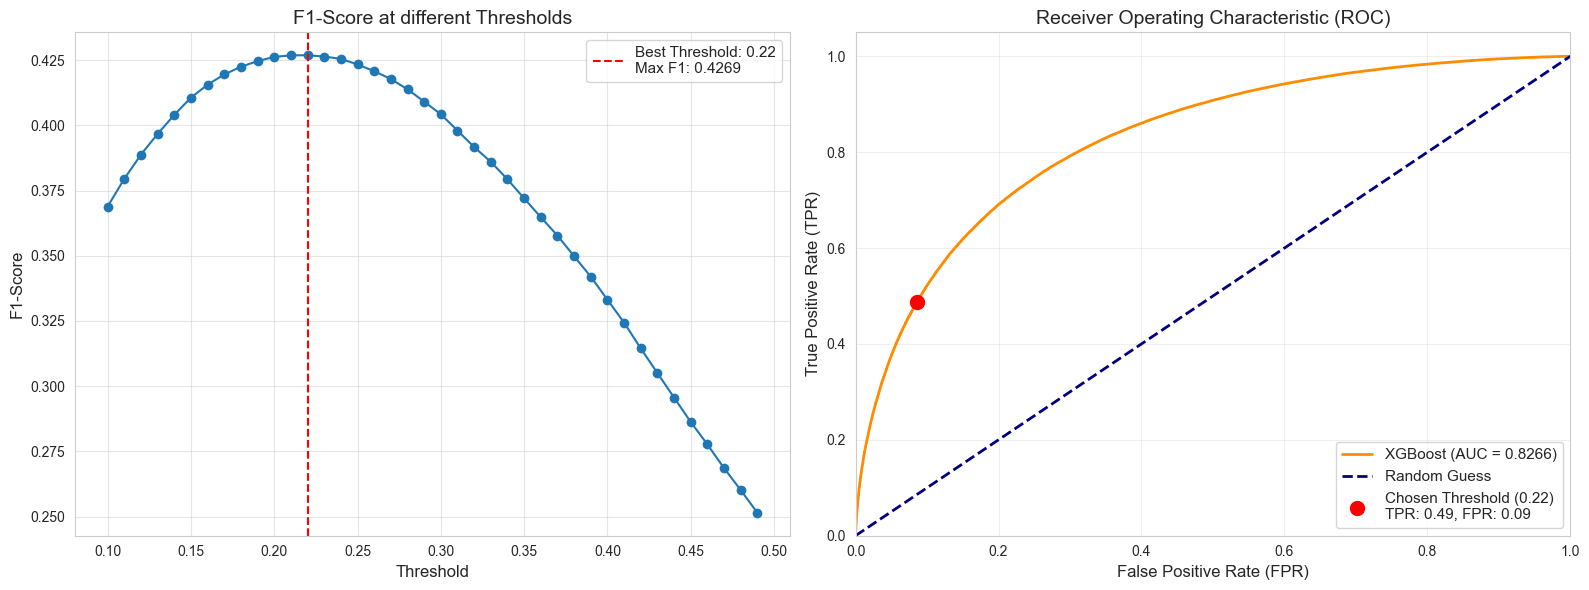

In [24]:
d_probs = xgb.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.50, 0.01) 
scores = []

for t in thresholds:
    preds = (d_probs > t).astype(int)
    score = f1_score(y_val, preds)
    scores.append(score)

best_score = max(scores)
best_thresh = thresholds[scores.index(best_score)]

print("--- Optimization Results ---")
print(f"Best Threshold: {best_thresh:.2f}")
print(f"Best F1-Score:  {best_score:.4f}")
print(f"(Score increased to {best_score:.4f} at Threshold {best_thresh:.2f})\n")


fpr, tpr, roc_thresholds = roc_curve(y_val, d_probs)
roc_auc = auc(fpr, tpr)

idx = np.argmin(np.abs(roc_thresholds - best_thresh))
best_fpr = fpr[idx]
best_tpr = tpr[idx]


fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

axes[0].plot(thresholds, scores, marker='o', color='tab:blue')
axes[0].set_title("F1-Score at different Thresholds", fontsize=14)
axes[0].set_xlabel("Threshold", fontsize=12)
axes[0].set_ylabel("F1-Score", fontsize=12)
axes[0].axvline(best_thresh, color='r', linestyle='--', label=f'Best Threshold: {best_thresh:.2f}\nMax F1: {best_score:.4f}')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.5)

# ROC Curve 
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

# Best Threshold
axes[1].scatter(best_fpr, best_tpr, color='red', s=100, zorder=5, 
                label=f'Chosen Threshold ({best_thresh:.2f})\nTPR: {best_tpr:.2f}, FPR: {best_fpr:.2f}')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
test_users = orders.filter(pl.col("eval_set") == "test").select(["user_id", "order_id"])

test_candidates = up_feats.join(test_users, on="user_id", how="inner")
test_df = test_candidates.join(user_feats, on="user_id", how="left")
test_df = test_df.join(prod_feats, on="product_id", how="left")



X_test = test_df.select(features).to_pandas()

test_probs = xgb.predict_proba(X_test)[:, 1]

test_preds = (test_probs > 0.21).astype(int)

results_df = test_df.select(['order_id', 'product_id']).to_pandas()
results_df['prediction'] = test_preds


In [26]:
final_report = test_df.select(['user_id', 'order_id', 'product_id']).to_pandas()


final_report['probability'] = test_probs


final_report = final_report[final_report['probability'] > 0.05]

products_pd = pd.read_csv(os.path.join(path,'products.csv'), usecols=['product_id', 'product_name'])
final_report = final_report.merge(products_pd, on='product_id', how='left')


final_report = final_report.sort_values(['user_id', 'probability'], ascending=[True, False])

final_report['rank'] = final_report.groupby('user_id').cumcount() + 1

print("--- Final Recommendation List ---")
print(final_report[['user_id', 'product_name', 'probability', 'rank']].head(10))
process_path = 'Process_Data'
final_report.to_csv(os.path.join(process_path,'reorder_recommendations.csv'), index=False)


--- Final Recommendation List ---
         user_id                                     product_name  \
464741         3                                  Organic Avocado   
1740913        3                  Vanilla Unsweetened Almond Milk   
2138378        3                             Organic Baby Spinach   
781134         3  Unsweetened Chocolate Almond Breeze Almond Milk   
1232480        3                                  Garlic Couscous   
1479431        3                Organic Peeled Whole Baby Carrots   
977486         3                                Electrolyte Water   
68447          3          Organic Lightly Salted Brown Rice Cakes   
423284         3                                     Strawberries   
2140213        3                        Crackers, Crispy, Cheddar   

         probability  rank  
464741      0.653717     1  
1740913     0.640271     2  
2138378     0.592971     3  
781134      0.312480     4  
1232480     0.265261     5  
1479431     0.256788     6  
977

In [27]:
final_report['probability'].describe()

count    2.367062e+06
mean     1.775357e-01
std      1.438983e-01
min      5.000002e-02
25%      7.695751e-02
50%      1.237448e-01
75%      2.253161e-01
max      9.708800e-01
Name: probability, dtype: float64

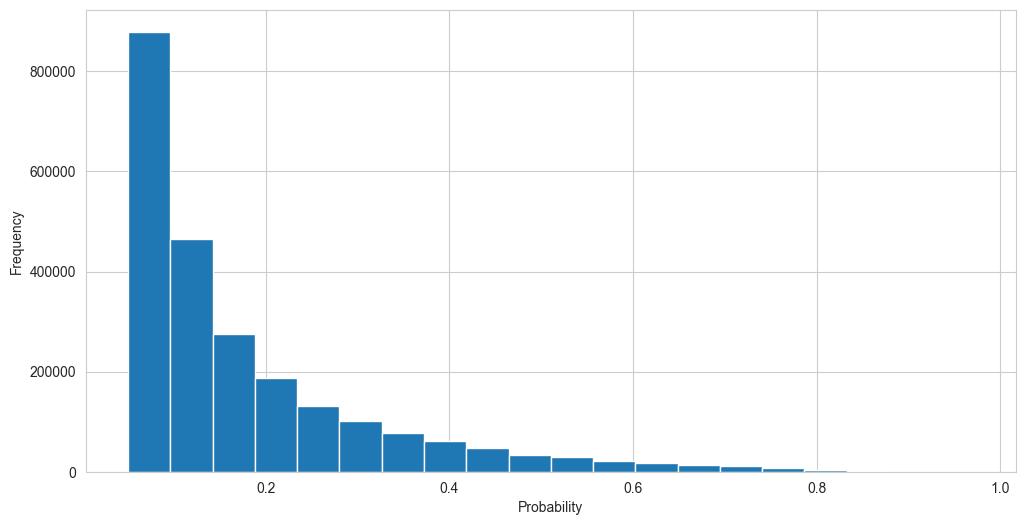

In [28]:
bins = np.arange(0, 1.1, 0.1)
pd.cut(final_report['probability'], bins=bins).value_counts(normalize=True).sort_index()
final_report['probability'].hist(bins=20)
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()


In [29]:
path = 'model'
model_filename = "xgb_reorder_model.json"
xgb.save_model(os.path.join(path,model_filename))

